# Case 4: Analyzing tariff-related acts in the EU Official Journal (2023-2025)

In [14]:
from bulletin.eurlex.api.client import EurlexBulletinClient

# Get the dataset of acts mentioning "tariff" in the title, in English language, between 2023 and 2025.
client = EurlexBulletinClient()

TITLE_CONTAINS = "tariff"
LANGUAGE = "ENG"

# Ask get_acts to extract all metadata directly as a DataFrame.
acts_df = client.get_acts(
    date="2023-01-01",
    date_end="2025-12-31",
    title_contains=TITLE_CONTAINS,
    language=LANGUAGE,
    output_format="df",
)

print(acts_df.head())
print(f"Total acts retrieved: {len(acts_df)}")

                                           celex_uri act_number  \
0  http://publications.europa.eu/resource/celex/3...        254   
1  http://publications.europa.eu/resource/celex/2...        NaN   
2  http://publications.europa.eu/resource/celex/6...        NaN   
3  http://publications.europa.eu/resource/celex/3...       2583   
4  http://publications.europa.eu/resource/celex/6...        NaN   

                                               title        date section_code  \
0  Commission Implementing Regulation (EU) 2023/2...  2023-02-07          NaN   
1  Notice concerning the date of entry into force...  2023-02-13          NaN   
2  Case T-721/21: Order of the General Court of 7...  2023-02-20          NaN   
3  Corrigendum to Council Regulation (EU) 2022/25...  2023-02-23          NaN   
4  Case T-566/21: Order of the General Court of 7...  2023-02-27          NaN   

  subsection_code  category_code  \
0             NaN       REG_IMPL   
1             NaN         NOTICE   
2 

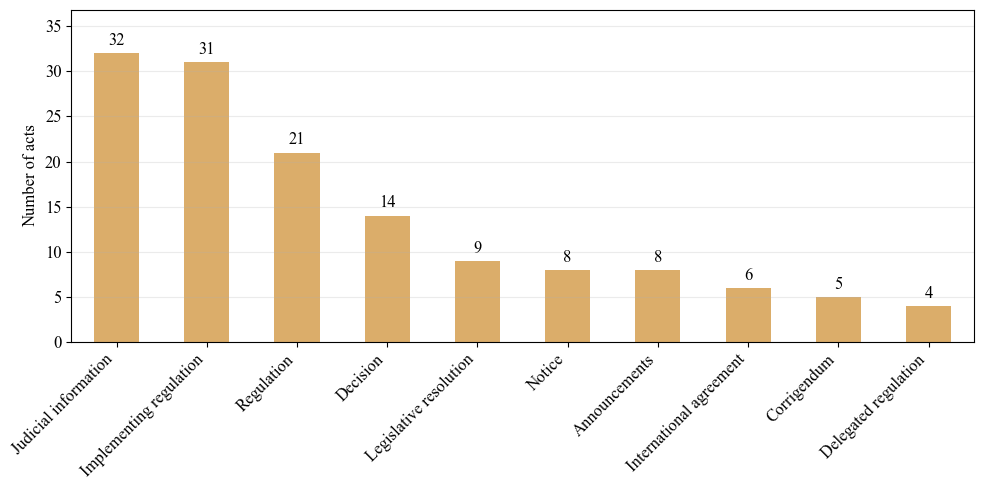

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 10,          # Base font size
    "axes.titlesize": 12,     # Title size
    "axes.labelsize": 12,     # Axis label size
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# Plot the typology of acts mentioned in the title.
typology_column = "category_label" if "category_label" in acts_df.columns else "category_type"
typology_counts = acts_df[typology_column].value_counts().sort_values(ascending=False)

ax = typology_counts.plot(kind="bar", figsize=(10, 5), color="#DBAD6A")

ax.set_xlabel("")
ax.set_ylabel("Number of acts")
ax.grid(axis="y", alpha=0.25)
ax.tick_params(axis="both", labelsize=12)
plt.xticks(rotation=45, ha="right")
ax.set_ylim(0, typology_counts.max() * 1.15)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{int(height)}',
        xy=(p.get_x() + p.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha='center',
        va='bottom',
        fontsize=12,
    )

plt.tight_layout()
plt.savefig("../figures/tariff-acts_categories.pdf", format="pdf", bbox_inches="tight")
plt.show()


Fetching content for 138 unique acts...


,celex_uri,top_entities
0,http://publications.europa.eu/resource/celex/3...,"Skyr, Iceland, LORI, the Member States, Canada..."
1,http://publications.europa.eu/resource/celex/2...,"New Zealand, the United Kingdom"
2,http://publications.europa.eu/resource/celex/6...,"Amsterdam, Netherlands, 17.1.2022"
3,http://publications.europa.eu/resource/celex/3...,"L 56/29 Corrigendum, Regulation"
4,http://publications.europa.eu/resource/celex/6...,"Schwertberg, Austria"
...,...,...
133,http://publications.europa.eu/resource/celex/6...,
134,http://publications.europa.eu/resource/celex/3...,
135,http://publications.europa.eu/resource/celex/3...,
136,http://publications.europa.eu/resource/celex/6...,


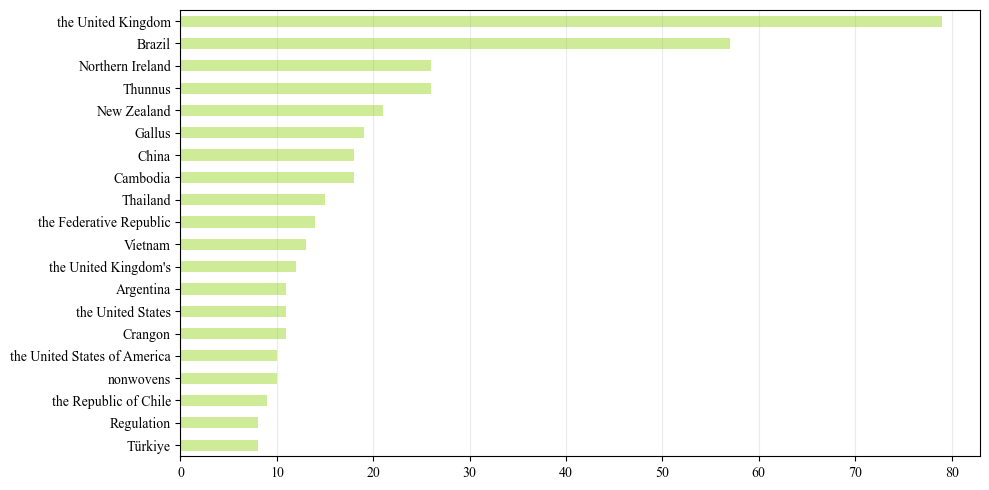

In [16]:
import re
from collections import Counter

import pandas as pd
import spacy

nlp = spacy.load("en_core_web_sm")

# Limit the labels to GPE (Geopolitical Entity).
ENTITY_LABELS = {"GPE"}
ENTITY_STOP_TEXTS = {"European Union", "European Commission", "Council of the European Union", "European Parliament", "European Council", "EU", "E.U.", "EC", "ECJ", "CJEU", "Brussels"}


def html_to_text(content_html):
    text = re.sub(r"<script.*?</script>|<style.*?</style>", " ", content_html, flags=re.I | re.S)
    text = re.sub(r"<[^>]+>", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def plot_top(counter, title, color):
    if not counter:
        print(f"No data to plot for: {title}")
        return
    labels, values = zip(*counter.most_common(20))
    ax = pd.Series(values[::-1], index=labels[::-1]).plot(kind="barh", figsize=(10, 5), color=color)
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.savefig(f"../figures/{title.replace(' ', '_').lower()}.pdf", format="pdf", bbox_inches="tight")
    plt.show()

print(f"Fetching content for {len(acts_df)} unique acts...")
rows, global_entities = [], Counter()

for _, act in acts_df.iterrows():
    try:
        html = client.get_act_content(act["celex_uri"], language=LANGUAGE)
        doc = nlp(html_to_text(html)[: nlp.max_length])
    except Exception as exc:
        print(f"Warning: could not analyze {act['celex_uri']}: {exc}")
        continue

    entities = [
        re.sub(r"\s+", " ", ent.text).strip() for ent in doc.ents
        if ent.label_ in ENTITY_LABELS
        and ent.text.strip() not in ENTITY_STOP_TEXTS
        and len(ent.text.strip()) > 2
    ]

    entity_counts = Counter(entities)
    global_entities.update(entity_counts)
    rows.append({
        "celex_uri": act["celex_uri"],
        "top_entities": ", ".join(entity for entity, _ in entity_counts.most_common(6)),
    })

analysis_df = pd.DataFrame(rows)
display(analysis_df)
plot_top(global_entities, f"Most Frequent Geopolitical Entities", "#CEEC97")
